<a href="https://colab.research.google.com/github/Faspeice/ml/blob/lr5/lr5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 5
# Кластеризация

**Цель работы**: научиться производить кластерный анализ данных с
использованием метода К-средних.

Выполним кластеризацию набора данных `Customers`. Набор данных описывает клиентов магазина и включает следующие атрибуты:

- **Customer ID** – идентификатор клиента.  
- **Gender** – пол.  
- **Age** – возраст.  
- **Annual Income** – годовой доход.  
- **Spending Score** – оценка расходов, присваиваемая магазином на основе поведения покупателя и характера расходов.  
- **Profession** – профессия.  
- **Work Experience** – опыт работы (в годах).  
- **Family Size** – размер семьи.   

 ## Импортируем библиотеки и загружаем данные

In [886]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [887]:
url = "https://raw.githubusercontent.com/faspeice/ml/lr5/Customers.csv"
df = pd.read_csv(url)

df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


## Получим информацию о датасете

In [888]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


## Проверяем наличие пропущенных значений и выбросов

In [889]:
print(df.isnull().sum())

CustomerID                 0
Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64


In [890]:
# Заменим пропуски категориальный данных наиболее часто встречающимся значением
mode_value = df['Profession'].mode()
df['Profession'] = df['Profession'].fillna(mode_value[0])

print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income ($)         0
Spending Score (1-100)    0
Profession                0
Work Experience           0
Family Size               0
dtype: int64


## Исключаем невлияющие признаки

In [891]:
df_copy = df.copy()
df_copy.drop('CustomerID', axis = 1, inplace = True)
df_copy.drop('Profession', axis = 1, inplace = True)
df_copy.drop('Gender', axis = 1, inplace = True)


## Применяем операцию нормализации для численной устойчивости

In [892]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
scaler = StandardScaler()
scaler

StandardScaler()

## Приведем данные к единому масштабу

In [893]:
X = scaler.fit_transform(df_copy)
X[:5]

array([[-1.05408932, -2.09350095, -0.42833854, -0.79120713,  0.11749744],
       [-0.98372287, -1.65613312,  1.07554599, -0.28116224, -0.39005088],
       [-1.0189061 , -0.54084515, -1.6099621 , -0.79120713, -1.40514752],
       [-0.91335643, -1.13129172,  0.93231889, -1.04622958, -0.8975992 ],
       [-0.63189066, -1.59052794, -0.39253176, -0.53618469,  1.13259408]])

## Определяем оптимальное количество кластеров с помощью метода локтя

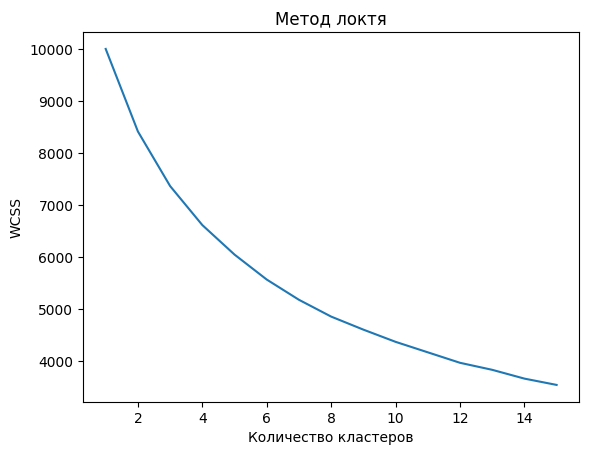

In [894]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 16):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 16), wcss)
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.show()

Заметим, что явного локтя нет, и данные кластеризуются неявно. Понизим размерность признаков, исключив не слишком
существенные для категоризации клиентов магазина

In [895]:
df_copy.drop('Work Experience', axis = 1, inplace = True)
df_copy.drop('Family Size', axis = 1, inplace = True)
# Заново приведем данные к единому масштабу
X = scaler.fit_transform(df_copy)

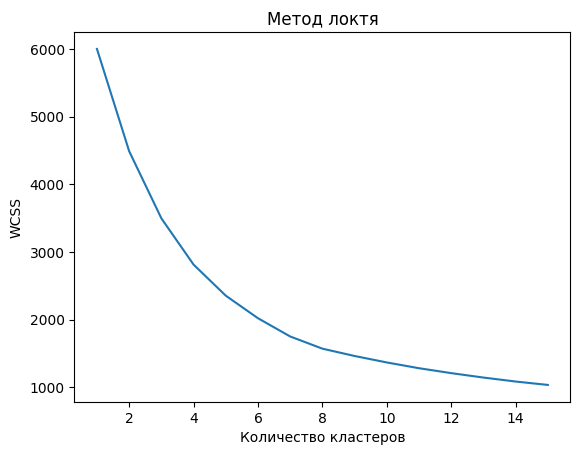

In [896]:
wcss = []
for i in range(1, 16):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 16), wcss)
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.show()

Теперь есть явный локоть при количестве кластеров: 6

## Обучаем модель кластеризации

In [897]:
kmeans = KMeans(n_clusters=6, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(X)

KMeans(n_clusters=6, n_init=10, random_state=42)

## Предсказываем кластеры и визуализируем результаты

In [898]:
clusters = kmeans.predict(X)

df_copy['cluster'] = clusters
df_copy.head()

,Age,Annual Income ($),Spending Score (1-100),cluster
0,19,15000,39,1
1,21,35000,81,2
2,20,86000,6,1
3,23,59000,77,2
4,31,38000,40,1


## Визуализация результатов

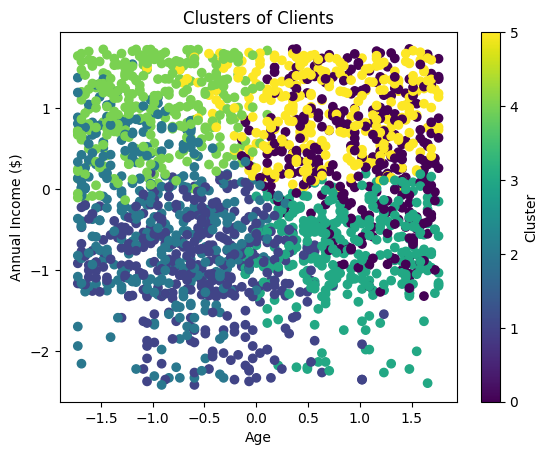

In [900]:
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Annual Income ($)')
plt.title('Clusters of Clients')
plt.colorbar(label='Cluster')
plt.show()

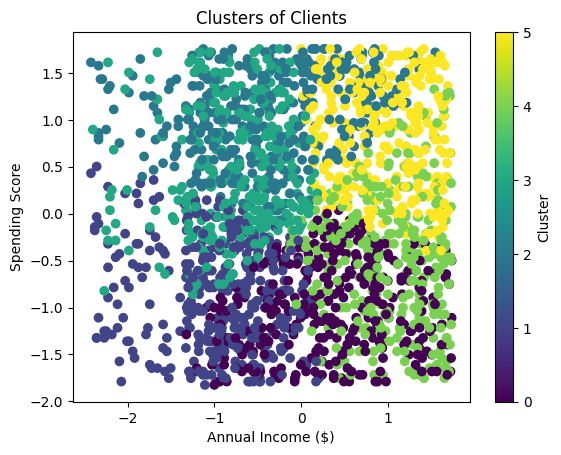

In [901]:
plt.scatter(X[:, 1], X[:, 2], c=clusters, cmap='viridis')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score')
plt.title('Clusters of Clients')
plt.colorbar(label='Cluster')
plt.show()

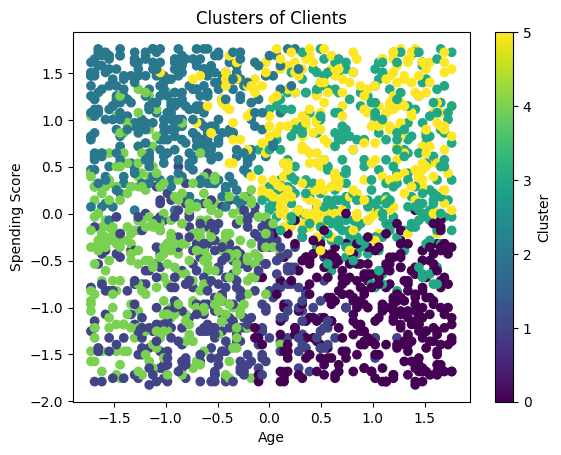

In [902]:
plt.scatter(X[:, 0], X[:, 2], c=clusters, cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Clusters of Clients')
plt.colorbar(label='Cluster')
plt.show()

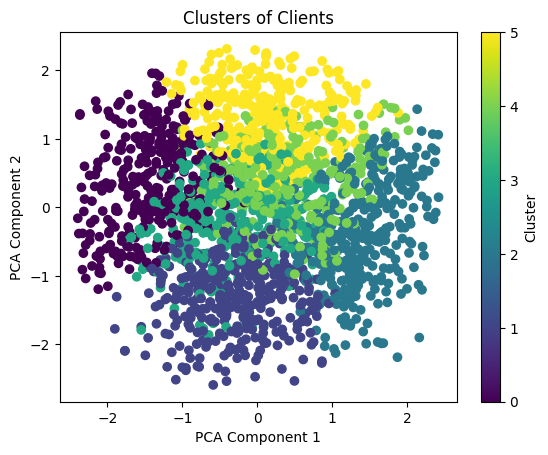

In [899]:
from sklearn.decomposition import PCA

# Уменьшаем размерность до 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Визуализация
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clusters of Clients')
plt.colorbar(label='Cluster')
plt.show()

### Группируем по кластерам и анализируем средние значения в каждом кластере

In [903]:
cluster_groups = df_copy.groupby('cluster')

cluster_groups.mean()

,Age,Annual Income ($),Spending Score (1-100)
cluster,,,
0,77.226006,127894.359133,22.743034
1,34.128767,67374.087671,26.701370
2,22.736264,92679.629121,80.082418
3,74.414110,76382.279141,63.874233
4,21.491961,156723.266881,38.655949
5,68.488746,154936.588424,73.434084


**Интерпретация результатов**

- **Кластер 0**: Пожилые клиенты  с умеренным доходом, но очень низкими тратами — экономные, скорее всего, на пенсии.  
- **Кластер 1**: Молодые с низким доходом и низкими тратами — возможно, начинающие специалисты или малообеспеченные люди.  
- **Кластер 2**: Очень молодые со средним доходом, но очень высокими тратами — любят тратить, типичные шопоголики.  
- **Кластер 3**: Пожилые с низким доходом, но умеренно высокими тратами — активные, позволяют себе развлечения.  
- **Кластер 4**: Очень молодые с очень высоким доходом, но умеренными тратами — богатые, но сдержанные (например, стартаперы или наследники).  
- **Кластер 5**: Зрелые с очень высоким доходом и высокими тратами — успешные «люксовые» потребители, готовые тратить на премиум-товары.  

In [909]:
# Распределение профессий по кластерам
profession_by_cluster = df.groupby('cluster')['Profession'].value_counts(normalize=True).unstack(fill_value=0)
print(profession_by_cluster)

Profession    Artist    Doctor  Engineer  Entertainment  Executive  \
cluster                                                              
0           0.359133  0.089783  0.108359       0.102167   0.068111   
1           0.298630  0.076712  0.087671       0.112329   0.090411   
2           0.365385  0.096154  0.071429       0.101648   0.085165   
3           0.337423  0.064417  0.088957       0.141104   0.052147   
4           0.286174  0.064309  0.073955       0.115756   0.083601   
5           0.289389  0.090032  0.109325       0.131833   0.077170   

Profession  Healthcare  Homemaker    Lawyer  Marketing  
cluster                                                 
0             0.145511   0.030960  0.058824   0.037152  
1             0.169863   0.052055  0.068493   0.043836  
2             0.153846   0.019231  0.060440   0.046703  
3             0.174847   0.027607  0.079755   0.033742  
4             0.196141   0.028939  0.086817   0.064309  
5             0.180064   0.019293  0.073

In [910]:
# Распределение пола по кластерам
gender_by_cluster = df.groupby('cluster')['Gender'].value_counts(normalize=True).unstack(fill_value=0)
print(gender_by_cluster)

Gender     Female      Male
cluster                    
0        0.541796  0.458204
1        0.619178  0.380822
2        0.549451  0.450549
3        0.598160  0.401840
4        0.614148  0.385852
5        0.639871  0.360129
